In [15]:
import polars as pl
import glob
import os.path
import matplotlib.pyplot as plt

In [16]:
SCALED=1000
HASH_THRESHOLD=0 # int(20000 / SCALED)
CONTAINMENT_THRESHOLD=0


CSVPATH=f'/home/ctbrown/scratch3/2025-workflow-core99/outputs.cds/cds3-anchor-genes/manysearch.3216.csv'
#CSVPATH=f'/home/ctbrown/scratch3/2025-workflow-core99/outputs.cds/cds3-genes/manysearch.3216.csv'

In [17]:
CORENAMES = set([ x.strip() for x in open('../inputs.cds/names.list') ])

In [18]:
dflist = []
#ms_filenames = glob.glob('../manysearch-3216/*.cds.x.3216.manysearch.csv')
ms_filenames = glob.glob(CSVPATH)
for filename in ms_filenames:
    print(os.path.basename(filename))
    df = pl.read_csv(filename)
    dflist.append(df)

df = pl.concat(dflist)

manysearch.3216.csv


In [19]:
df

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
"""s__Prevotella sp000434975""","""59c9697c26d43c92b5035a90821592…","""SRR11126298""",0.666667,2,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000007,0.666667,1.5,1.5,0.5,0.980877,0.56916,0.775019,0.980877,3,1158696
"""s__Bariatricus sp004560705""","""b4d3145d33c3e1399735bc3dd6116e…","""SRR11126298""",1.0,3,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000011,1.0,1.333333,1.0,0.471405,1.0,0.580256,0.790128,1.0,4,1158696
"""s__Mogibacterium_A kristiansen…","""692d56163718e45a4074ef5c82cf4f…","""SRR11126298""",1.0,1,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000004,1.0,8.0,8.0,0.0,1.0,0.55068,0.77534,1.0,8,1158696
"""s__Sodaliphilus sp004557565""","""b460a850a6ba2952b3f40d55ebf9b5…","""SRR11126298""",0.75,3,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000011,0.75,14.333333,16.0,3.858612,0.986394,0.580256,0.783325,0.986394,43,1158696
"""s__Lactobacillus amylovorus""","""c2a5ec590ef0f1adf66a2069d19185…","""SRR11126298""",0.5,1,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000004,0.5,2.0,2.0,0.0,0.967532,0.55068,0.759106,0.967532,2,1158696
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Cryptobacteroides sp0004349…","""934758d1ef02329909c4ea9f5c7df2…","""SRR11185262""",1.0,2,21,1000,"""DNA""","""b9b4b9553722c890e35095734a292c…",0.000001,1.0,4.5,4.5,0.5,1.0,0.520515,0.760258,1.0,9,16945253
"""s__Ornithospirochaeta sp022785…","""285f3ff6feecea4257736e0cc6a1ea…","""SRR11185262""",0.333333,1,21,1000,"""DNA""","""b9b4b9553722c890e35095734a292c…",5.5472e-7,0.333333,1.0,1.0,0.0,0.94903,0.503615,0.726323,0.94903,1,16945253
"""s__Cryptobacteroides sp0004326…","""8c802dbb76eddb3d00a4f0b3c3b579…","""SRR11185262""",0.5,1,21,1000,"""DNA""","""b9b4b9553722c890e35095734a292c…",5.5472e-7,0.5,2.0,2.0,0.0,0.967532,0.503615,0.735573,0.967532,2,16945253


In [20]:
len(df.filter(pl.col("intersect_hashes") >= HASH_THRESHOLD))

32599

In [21]:
for row in df.filter(pl.col("intersect_hashes") >= HASH_THRESHOLD)['query_name'].value_counts().with_columns(
    (pl.col("count") / 3216 * 100).alias("percent")
).sort(by='percent', descending=True).iter_rows(named=True):
    name = row['query_name']
    if name in CORENAMES:
        name = '** ' + name
    print(f"{row['percent']:.1f}% {name} ")

94.5% ** s__Sodaliphilus sp004557565 
86.2% ** s__Cryptobacteroides sp034089285 
85.0% ** s__Bariatricus sp004560705 
81.9% ** s__Lactobacillus amylovorus 
77.8% ** s__Prevotella sp002251295 
72.9% ** s__Mogibacterium_A kristiansenii 
71.8% ** s__Prevotella sp000434975 
66.5% ** s__Colivicinus sp002299675 
62.3% ** s__Fimisoma sp002320005 
55.6% ** s__Cryptobacteroides sp000434935 
55.5% ** s__Ornithospirochaeta sp022785155 
55.5% ** s__UBA2868 sp004552595 
53.7% ** s__Floccifex porci 
51.9% ** s__Cryptobacteroides sp000432655 
42.4% ** s__Cryptobacteroides sp900546925 


In [22]:
df

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
"""s__Prevotella sp000434975""","""59c9697c26d43c92b5035a90821592…","""SRR11126298""",0.666667,2,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000007,0.666667,1.5,1.5,0.5,0.980877,0.56916,0.775019,0.980877,3,1158696
"""s__Bariatricus sp004560705""","""b4d3145d33c3e1399735bc3dd6116e…","""SRR11126298""",1.0,3,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000011,1.0,1.333333,1.0,0.471405,1.0,0.580256,0.790128,1.0,4,1158696
"""s__Mogibacterium_A kristiansen…","""692d56163718e45a4074ef5c82cf4f…","""SRR11126298""",1.0,1,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000004,1.0,8.0,8.0,0.0,1.0,0.55068,0.77534,1.0,8,1158696
"""s__Sodaliphilus sp004557565""","""b460a850a6ba2952b3f40d55ebf9b5…","""SRR11126298""",0.75,3,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000011,0.75,14.333333,16.0,3.858612,0.986394,0.580256,0.783325,0.986394,43,1158696
"""s__Lactobacillus amylovorus""","""c2a5ec590ef0f1adf66a2069d19185…","""SRR11126298""",0.5,1,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000004,0.5,2.0,2.0,0.0,0.967532,0.55068,0.759106,0.967532,2,1158696
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Cryptobacteroides sp0004349…","""934758d1ef02329909c4ea9f5c7df2…","""SRR11185262""",1.0,2,21,1000,"""DNA""","""b9b4b9553722c890e35095734a292c…",0.000001,1.0,4.5,4.5,0.5,1.0,0.520515,0.760258,1.0,9,16945253
"""s__Ornithospirochaeta sp022785…","""285f3ff6feecea4257736e0cc6a1ea…","""SRR11185262""",0.333333,1,21,1000,"""DNA""","""b9b4b9553722c890e35095734a292c…",5.5472e-7,0.333333,1.0,1.0,0.0,0.94903,0.503615,0.726323,0.94903,1,16945253
"""s__Cryptobacteroides sp0004326…","""8c802dbb76eddb3d00a4f0b3c3b579…","""SRR11185262""",0.5,1,21,1000,"""DNA""","""b9b4b9553722c890e35095734a292c…",5.5472e-7,0.5,2.0,2.0,0.0,0.967532,0.503615,0.735573,0.967532,2,16945253


In [23]:
SUB_SPECIES2=(
             's__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',
#             's__Prevotella sp000434975',
#             's__Holdemanella porci',
)

for row in df.filter(pl.col("intersect_hashes") >= HASH_THRESHOLD)['query_name'].value_counts().with_columns(
    (pl.col("count") / 3216 * 100).alias("percent")
).sort(by='percent').iter_rows(named=True):
    if row["query_name"] in SUB_SPECIES2:
        print(f"{row['percent']:.1f}% {row['query_name']} ")

42.4% s__Cryptobacteroides sp900546925 
72.9% s__Mogibacterium_A kristiansenii 
77.8% s__Prevotella sp002251295 


In [24]:
for row in df.filter(pl.col("intersect_hashes") >= HASH_THRESHOLD)['query_name'].value_counts().with_columns(
    (pl.col("count") / 3216 * 100).alias("percent")
).sort(by='percent').iter_rows(named=True):
    print(f"{row['percent']:.1f}% {row['query_name']} ")

42.4% s__Cryptobacteroides sp900546925 
51.9% s__Cryptobacteroides sp000432655 
53.7% s__Floccifex porci 
55.5% s__UBA2868 sp004552595 
55.5% s__Ornithospirochaeta sp022785155 
55.6% s__Cryptobacteroides sp000434935 
62.3% s__Fimisoma sp002320005 
66.5% s__Colivicinus sp002299675 
71.8% s__Prevotella sp000434975 
72.9% s__Mogibacterium_A kristiansenii 
77.8% s__Prevotella sp002251295 
81.9% s__Lactobacillus amylovorus 
85.0% s__Bariatricus sp004560705 
86.2% s__Cryptobacteroides sp034089285 
94.5% s__Sodaliphilus sp004557565 


In [25]:
manysearch_df = df.with_columns(
    pl.col("query_name").alias("species"),
    pl.col("match_name").alias("metag"),
    (pl.col("intersect_hashes") * pl.col("scaled") / pl.col("containment")).alias("sketch_size"),
)
manysearch_df = manysearch_df.with_columns(
    (pl.col('intersect_hashes')*1000).alias('intersect_bp'),
    (pl.col('n_weighted_found')*1000).alias('weighted_bp'),
)


In [26]:
manysearch_df

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes,species,metag,sketch_size,intersect_bp,weighted_bp
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,f64,i64,i64
"""s__Prevotella sp000434975""","""59c9697c26d43c92b5035a90821592…","""SRR11126298""",0.666667,2,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000007,0.666667,1.5,1.5,0.5,0.980877,0.56916,0.775019,0.980877,3,1158696,"""s__Prevotella sp000434975""","""SRR11126298""",3000.0,2000,3000
"""s__Bariatricus sp004560705""","""b4d3145d33c3e1399735bc3dd6116e…","""SRR11126298""",1.0,3,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000011,1.0,1.333333,1.0,0.471405,1.0,0.580256,0.790128,1.0,4,1158696,"""s__Bariatricus sp004560705""","""SRR11126298""",3000.0,3000,4000
"""s__Mogibacterium_A kristiansen…","""692d56163718e45a4074ef5c82cf4f…","""SRR11126298""",1.0,1,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000004,1.0,8.0,8.0,0.0,1.0,0.55068,0.77534,1.0,8,1158696,"""s__Mogibacterium_A kristiansen…","""SRR11126298""",1000.0,1000,8000
"""s__Sodaliphilus sp004557565""","""b460a850a6ba2952b3f40d55ebf9b5…","""SRR11126298""",0.75,3,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000011,0.75,14.333333,16.0,3.858612,0.986394,0.580256,0.783325,0.986394,43,1158696,"""s__Sodaliphilus sp004557565""","""SRR11126298""",4000.0,3000,43000
"""s__Lactobacillus amylovorus""","""c2a5ec590ef0f1adf66a2069d19185…","""SRR11126298""",0.5,1,21,1000,"""DNA""","""1fb43e54174036ee52d4d711702197…",0.000004,0.5,2.0,2.0,0.0,0.967532,0.55068,0.759106,0.967532,2,1158696,"""s__Lactobacillus amylovorus""","""SRR11126298""",2000.0,1000,2000
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Cryptobacteroides sp0004349…","""934758d1ef02329909c4ea9f5c7df2…","""SRR11185262""",1.0,2,21,1000,"""DNA""","""b9b4b9553722c890e35095734a292c…",0.000001,1.0,4.5,4.5,0.5,1.0,0.520515,0.760258,1.0,9,16945253,"""s__Cryptobacteroides sp0004349…","""SRR11185262""",2000.0,2000,9000
"""s__Ornithospirochaeta sp022785…","""285f3ff6feecea4257736e0cc6a1ea…","""SRR11185262""",0.333333,1,21,1000,"""DNA""","""b9b4b9553722c890e35095734a292c…",5.5472e-7,0.333333,1.0,1.0,0.0,0.94903,0.503615,0.726323,0.94903,1,16945253,"""s__Ornithospirochaeta sp022785…","""SRR11185262""",3000.0,1000,1000
"""s__Cryptobacteroides sp0004326…","""8c802dbb76eddb3d00a4f0b3c3b579…","""SRR11185262""",0.5,1,21,1000,"""DNA""","""b9b4b9553722c890e35095734a292c…",5.5472e-7,0.5,2.0,2.0,0.0,0.967532,0.503615,0.735573,0.967532,2,16945253,"""s__Cryptobacteroides sp0004326…","""SRR11185262""",2000.0,1000,2000


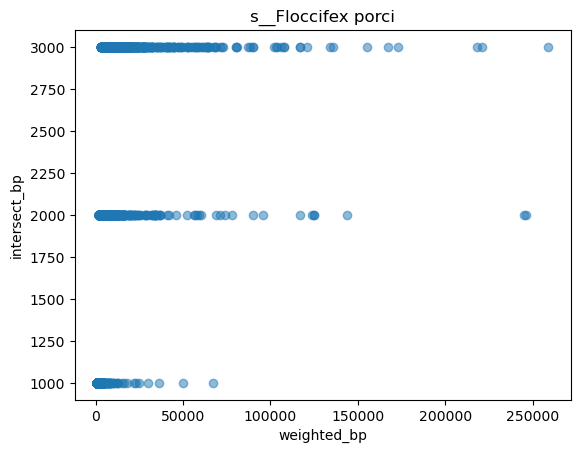

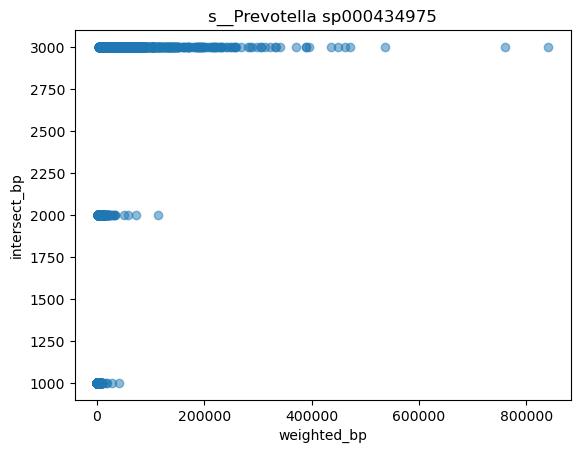

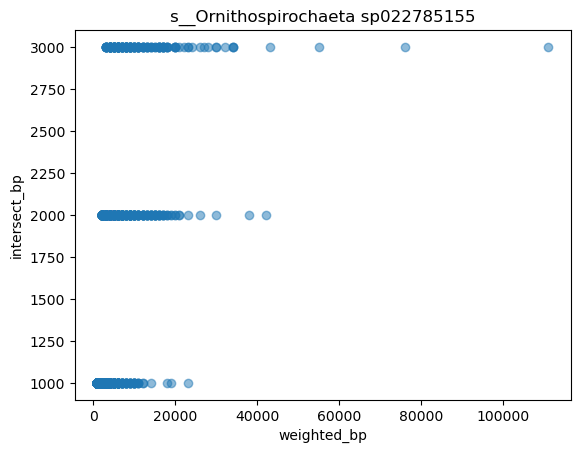

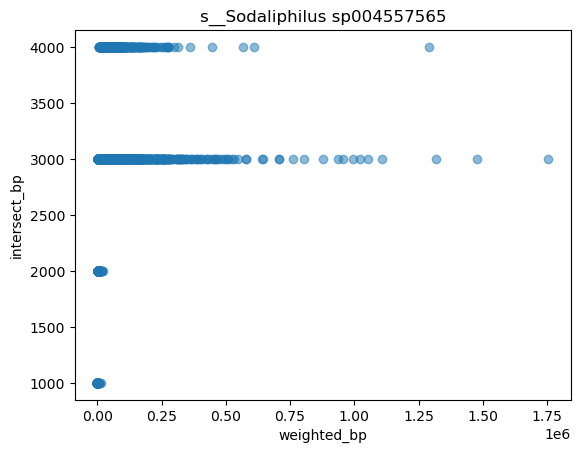

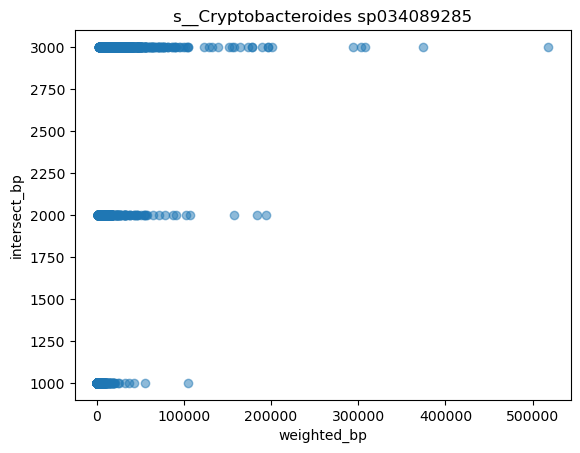

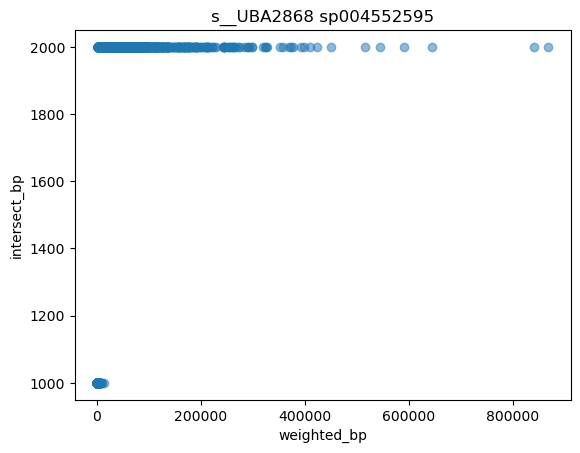

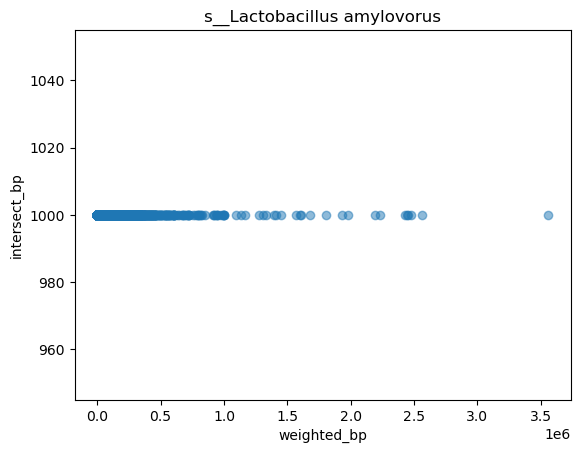

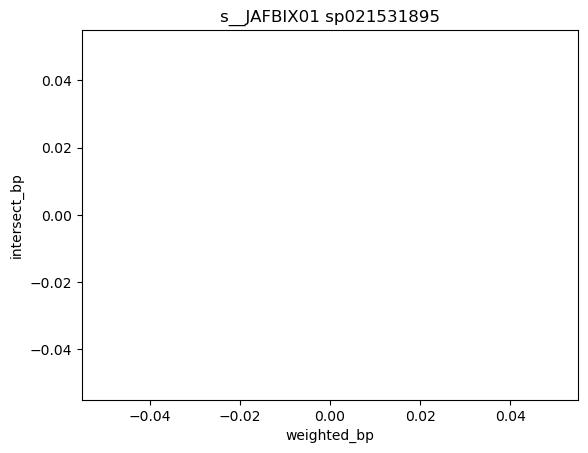

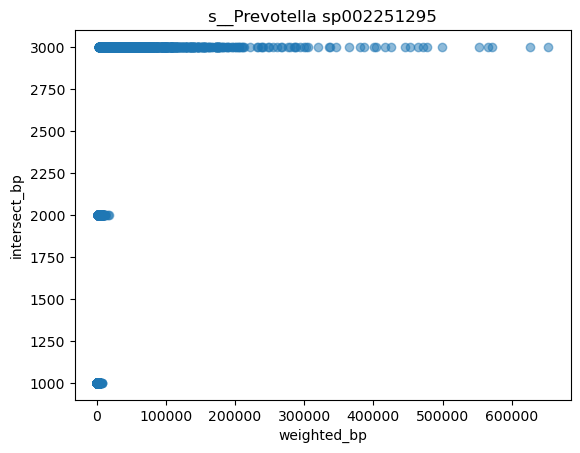

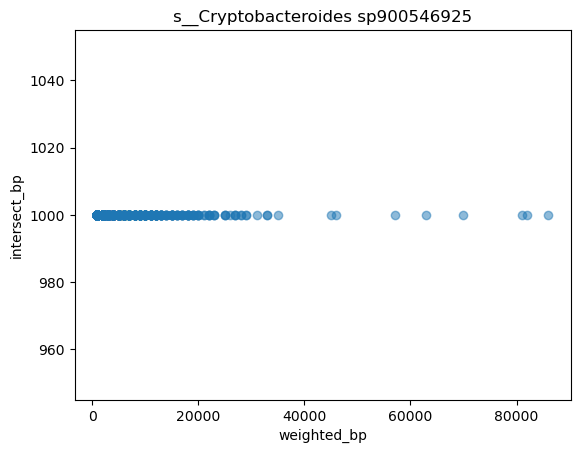

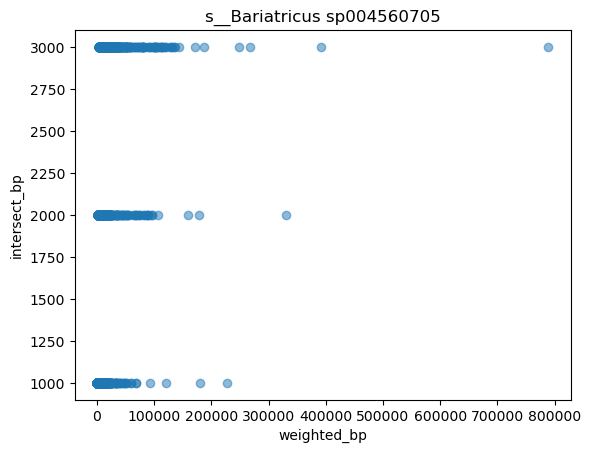

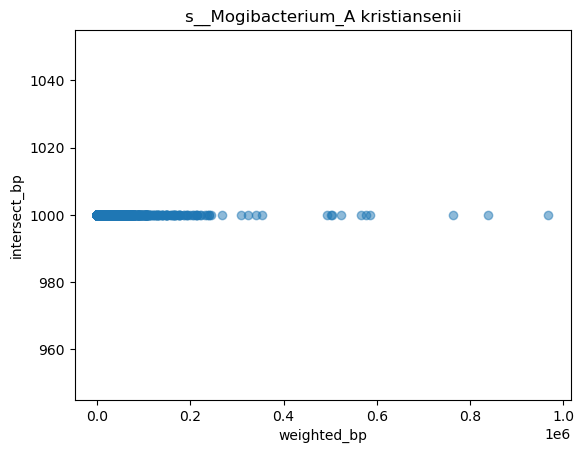

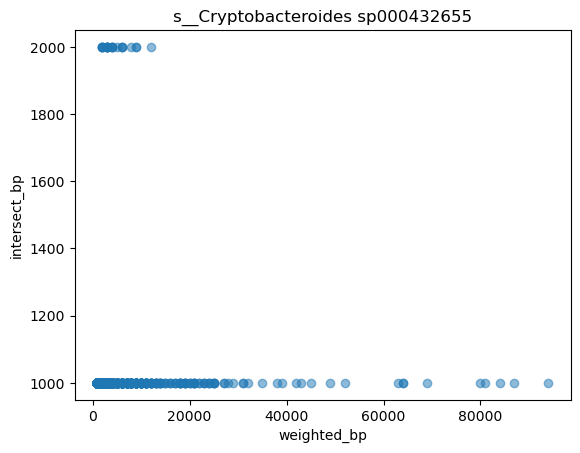

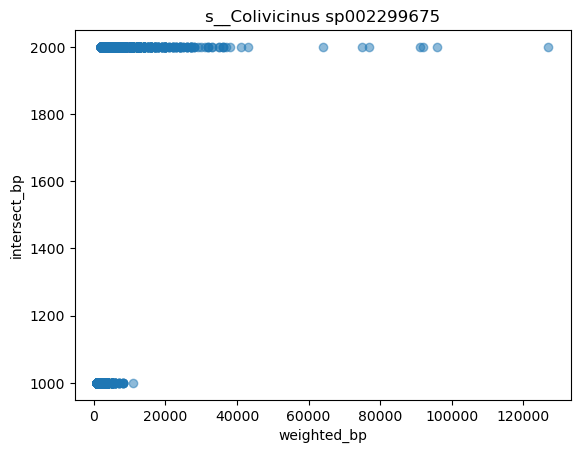

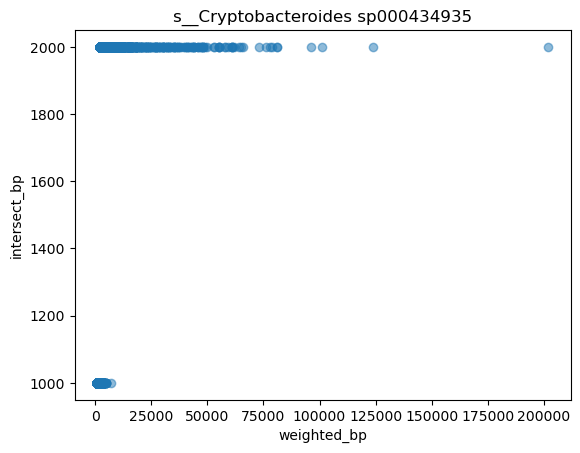

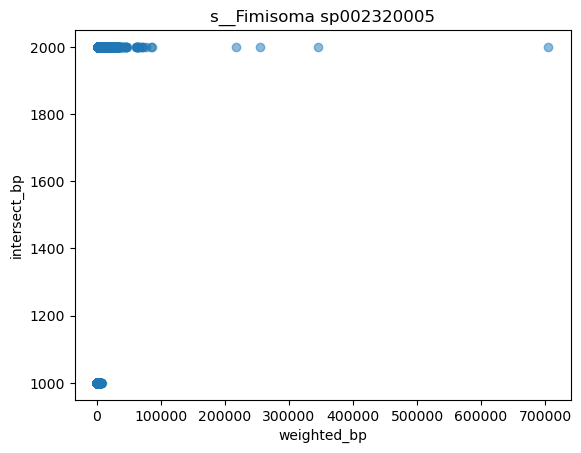

In [27]:
for species in CORENAMES:
    species_df = manysearch_df.filter(pl.col("species") == species)
    plt.plot(species_df['weighted_bp'], species_df['intersect_bp'], 'o', alpha=0.5)
    plt.xlabel('weighted_bp')
    plt.ylabel('intersect_bp')
    plt.title(species)
    plt.show()